In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chisquare, norm

In [2]:
data = {
    'Country': ['Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan', 
                'Bulgaria', 'Cyprus', 'Estonia', 'Finland', 'France', 
                'Georgia', 'Germany', 'Greece', 'Hungary', 'Iceland', 
                'Ireland', 'Israel', 'Italy', 'Kazakhstan', 'Liechtenstein', 
                'Lithuania', 'Malta', 'Monaco', 'Montenegro', 'Netherlands', 
                'Poland', 'Portugal', 'Romania', 'Serbia', 'Spain', 
                'Sweden', 'Tajikistan', 'Turkiye', 'Ukraine', 'United Kingdom', 
                'Uzbekistan'],
    'Value': [11.50, 4.20, 2.20, 31.90, 1.90, 
              8.60, 4.00, 2.70, 2.90, 102.00, 
              5.10, 37.50, 36.00, 13.20, 2.30, 
              6.60, 0.96, 57.70, 10.40, 0.12, 
              2.40, 3.60, 0.35, 2.40, 21.30, 
              19.70, 29.00, 2.40, 2.40, 93.80, 
              8.70, 1.40, 60.60, 2.50, 41.80, 
              10.10]
}
df = pd.DataFrame(data)

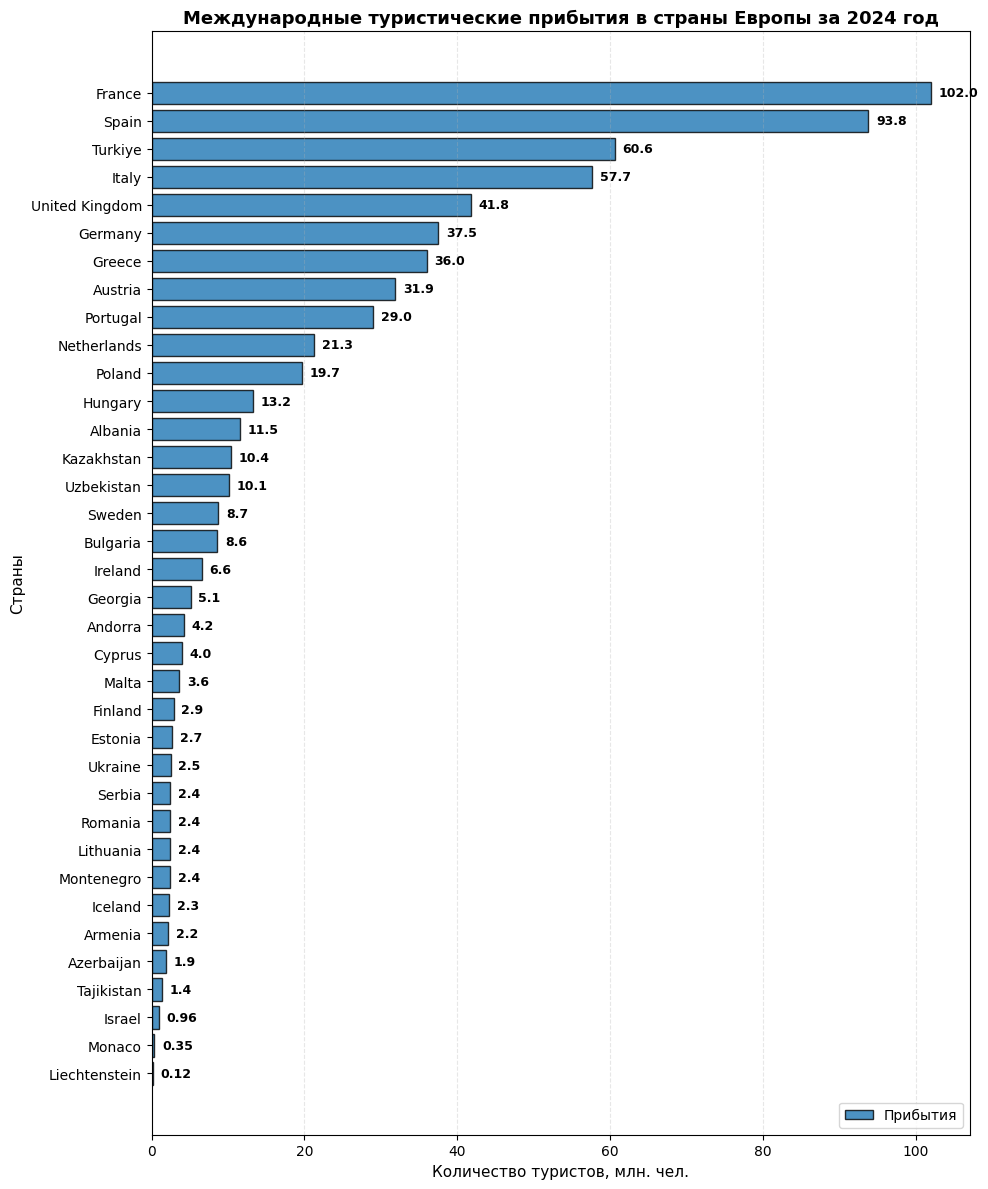

In [ ]:
# диаграмма для обзора данных

# Сортировка по значению для лучшей читаемости
df_sorted = df.sort_values('Value')

# Построение горизонтальной диаграммы
plt.figure(figsize=(10, 12))
plt.barh(df_sorted['Country'], df_sorted['Value'],
          edgecolor='black', alpha=0.8, label='Прибытия')

# Подписи осей, заголовок, легенда
plt.xlabel('Количество туристов, млн. чел.', fontsize=11)
plt.ylabel('Страны', fontsize=11)
plt.title('Международные туристические прибытия в страны Европы за 2024 год', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Добавление значений напротив каждой страны 
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    plt.text(row['Value'] + 1, i, f'{row["Value"]}', 
             va='center', fontsize=9, fontweight='bold')

# Отображение
plt.tight_layout()
plt.show()


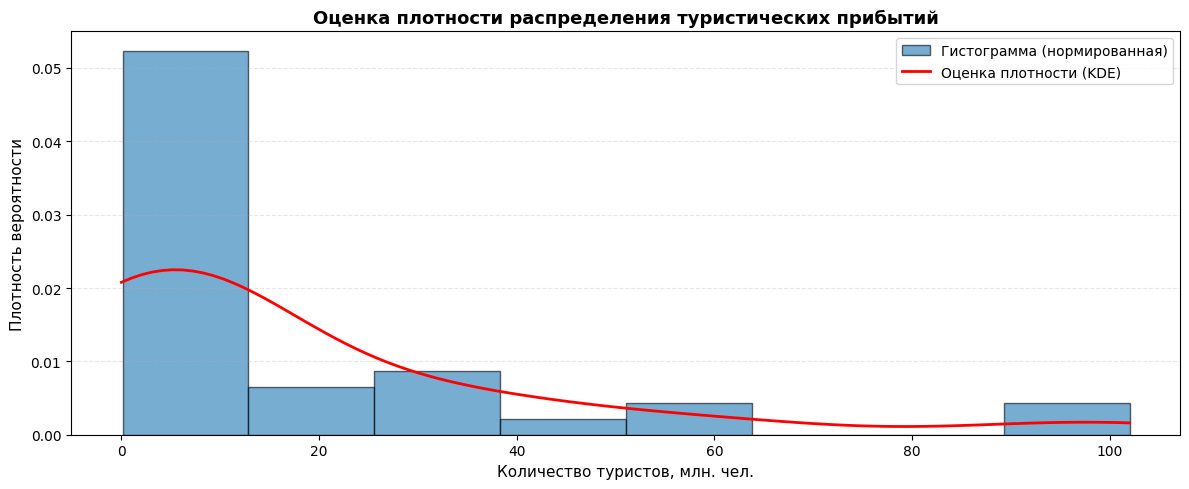

In [ ]:
# гистограмма нормального распределения

x = df['Value'].values
plt.figure(figsize=(12, 5))

# Гистограмма с нормировкой на плотность
plt.hist(x, bins=8, density=True, alpha=0.6, 
         edgecolor='black', label='Гистограмма (нормированная)')

# Оценка плотности (KDE)
kde = stats.gaussian_kde(x)
x_grid = np.linspace(0, x.max(), 100)
plt.plot(x_grid, kde(x_grid), 'r-', linewidth=2, label='Оценка плотности (KDE)')

# Подписи
plt.xlabel('Количество туристов, млн. чел.', fontsize=11)
plt.ylabel('Плотность вероятности', fontsize=11)
plt.title('Оценка плотности распределения туристических прибытий', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# характеристики данных до удаления топ-5 стран
x = np.array([11.50, 4.20, 2.20, 31.90, 1.90, 8.60, 4.00, 2.70, 2.90, 102.00, 
              5.10, 37.50, 36.00, 13.20, 2.30, 6.60, 0.96, 57.70, 10.40, 0.12, 
              2.40, 3.60, 0.35, 2.40, 21.30, 19.70, 29.00, 2.40, 2.40, 93.80, 
              8.70, 1.40, 60.60, 2.50, 41.80, 10.10])
print(f"Среднее: {np.mean(x):.2f}")
print(f"Медиана: {np.median(x):.2f}")
print(f"Стд. отклонение: {np.std(x):.2f}")
print(f"Асимметрия: {stats.skew(x):.2f}")
print(f"Эксцесс: {stats.kurtosis(x):.2f}")
print(f"Коэф. вариации: {np.std(x) / np.mean(x) * 100:.1f}%")

Среднее: 17.90
Медиана: 5.85
Стд. отклонение: 25.09
Асимметрия: 1.99
Эксцесс: 3.36
Коэф. вариации: 140.2%


In [ ]:
# характеристики данных после удаления топ-5 стран
x1 = np.array([11.50, 4.20, 2.20, 31.90, 1.90, 8.60, 4.00, 2.70, 2.90, 
              5.10, 37.50, 36.00, 13.20, 2.30, 6.60, 0.96, 10.40, 0.12, 
              2.40, 3.60, 0.35, 2.40, 21.30, 19.70, 29.00, 2.40, 2.40, 
              8.70, 1.40, 2.50, 10.10])

print(f"Среднее: {np.mean(x1):.2f}")
print(f"Медиана: {np.median(x1):.2f}")
print(f"Стд. отклонение: {np.std(x1):.2f}")
print(f"Асимметрия: {stats.skew(x1):.2f}")
print(f"Эксцесс: {stats.kurtosis(x1):.2f}")
print(f"Коэф. вариации: {np.std(x1) / np.mean(x1) * 100:.1f}%")

Среднее: 9.30
Медиана: 4.00
Стд. отклонение: 10.72
Асимметрия: 1.49
Эксцесс: 0.98
Коэф. вариации: 115.3%


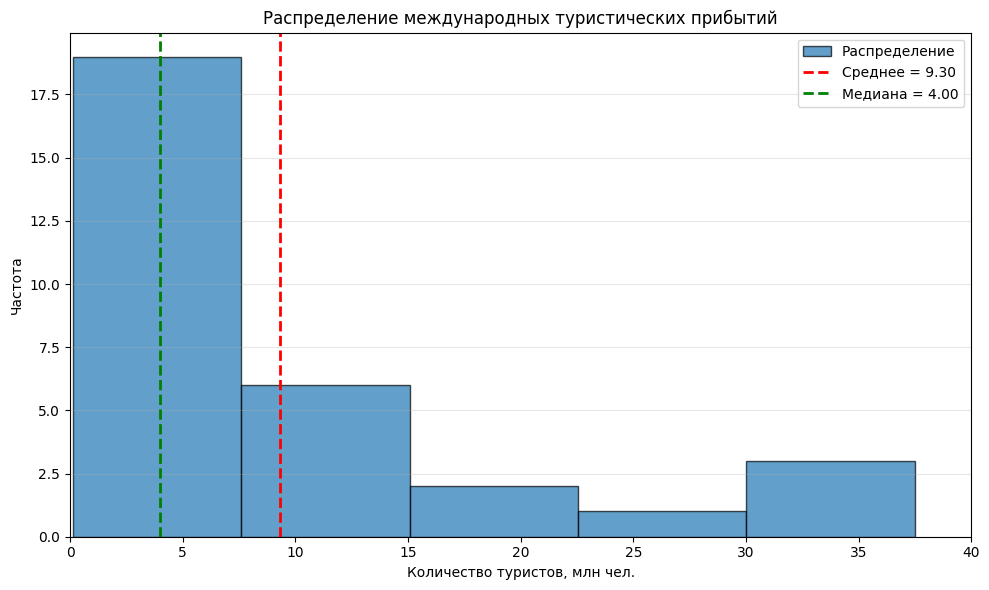

In [ ]:
# после удаления топ-5 стран
mean = np.mean(x1)
median = np.median(x1)

plt.figure(figsize=(10, 6))
plt.hist(x1, bins=5, edgecolor='black', alpha=0.7, label='Распределение')
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean:.2f}')
plt.axvline(median, color='green', linestyle='--', linewidth=2, label=f'Медиана = {median:.2f}')
plt.xlabel('Количество туристов, млн чел.')
plt.ylabel('Частота')
plt.title('Распределение международных туристических прибытий')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xlim(0, 40)
plt.tight_layout()
plt.show()

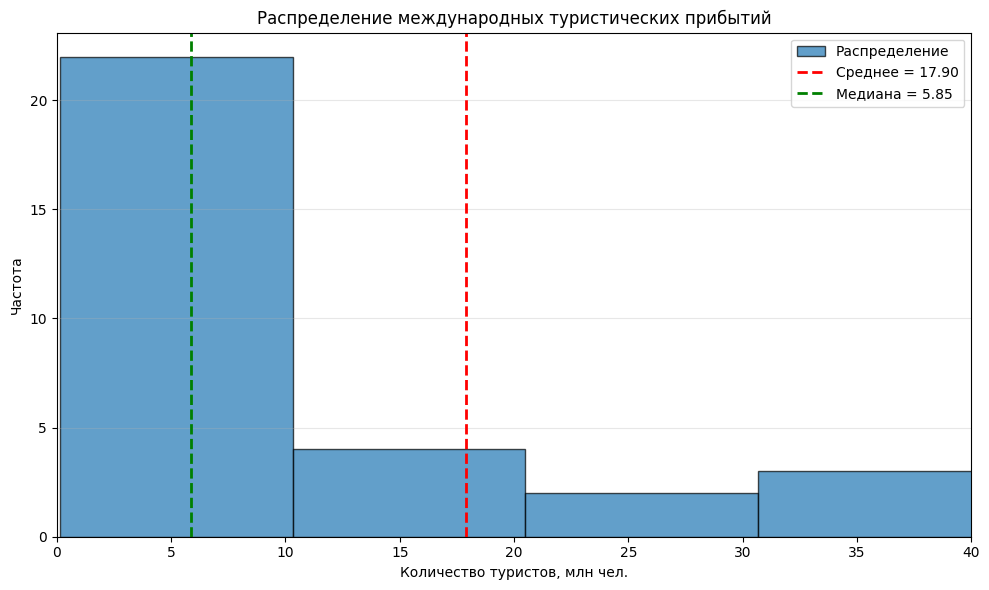

In [11]:
# до удаления топ-5 стран
mean = np.mean(x)
median = np.median(x)

plt.figure(figsize=(10, 6))
plt.hist(x, bins=10, edgecolor='black', alpha=0.7, label='Распределение')
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean:.2f}')
plt.axvline(median, color='green', linestyle='--', linewidth=2, label=f'Медиана = {median:.2f}')
plt.xlabel('Количество туристов, млн чел.')
plt.ylabel('Частота')
plt.title('Распределение международных туристических прибытий')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xlim(0, 40)
plt.tight_layout()
plt.show()

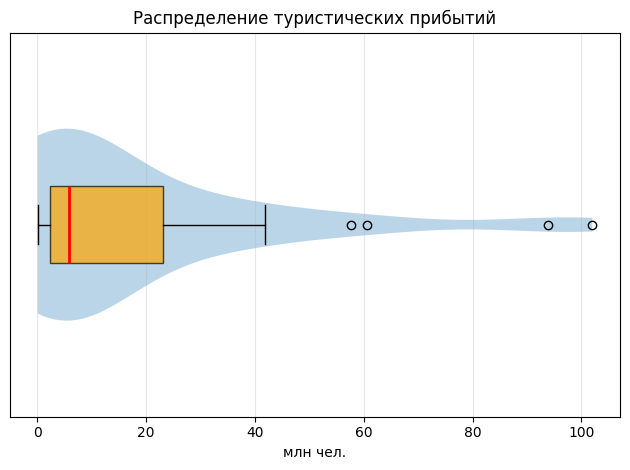

In [ ]:
# пункт 2.3 Boxplot
plt.violinplot(x, vert=False, showmedians=False, showextrema=False)
plt.boxplot(x, vert=False, widths=0.2, patch_artist=True, 
            boxprops=dict(facecolor='orange', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
plt.xlabel('млн чел.'); plt.title('Распределение туристических прибытий')
plt.grid(axis='x', alpha=0.3); plt.yticks([]); plt.tight_layout(); plt.show()